In [90]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import openpyxl

In [2]:
name_excelfile = "Catan_RawData_Copy.xlsx"
#open path to the excel file
path_to_folder = "/home/antoine-zijlstra/Coderen/WebsiteCatan/"
excel_path = Path(f"{path_to_folder}Data/Excel/Catan_RawData_Copy.xlsx")
##__file__ bestaat niet in jupyternotebook; alleen in python
print("excel_path:\n", excel_path)


excel_path:
 /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Excel/Catan_RawData_Copy.xlsx


In [3]:
#Getting sheet names
wb = openpyxl.load_workbook(excel_path)
sheet_names = wb.sheetnames
print(f"sheet_names:\n {sheet_names}")

sheet_names:
 ['Blad1']


In [4]:
#leest de hele file
file_original = pd.read_excel(excel_path, sheet_name="Blad1", engine="openpyxl")
#Create a copy of the original file
file = file_original.copy() 
print(f"file:\n {file}")

file:
         Datum Max Enzo Antoine  Ma  Pa    Begon     Bank    Comment  \
0  2022-08-09  11    9       7   5  10      NaN      NaN        NaN   
1  2022-08-13   4    9      11   9   9      NaN      NaN        NaN   
2  2022-08-16   8    8       7   6  11      NaN      NaN        NaN   
3  2022-08-19   6    7       9   8  11      NaN      NaN        NaN   
4  2022-08-20   8   11       8   7   5      NaN      NaN        NaN   
..        ...  ..  ...     ...  ..  ..      ...      ...        ...   
70 2026-05-10  11    6      10  10   7     Enzo       Ma  Moederdag   
71 2026-06-07   9   11       9  10   x  Antoine  Antoine        NaN   
72 2026-07-16  11    7       9   6   7       Ma       Ma     Ostuni   
73 2026-07-20   7    8       7  11   4     Enzo       Ma     Ostuni   
74 2026-07-21  11    6       9   8   7     Enzo      Max     Ostuni   

    Potjes(#)  Potjes in een jaar(#)  
0           1                      1  
1           2                      2  
2           3          

In [5]:
# Get all columns (except index/names)
data = file[["Datum", "Max", "Enzo", "Antoine", "Ma", "Pa", "Begon", "Bank", "Potjes(#)", "Potjes in een jaar(#)"]]
data["Datum"] = pd.to_datetime(data["Datum"], format="%d-%m-%Y") #The right format for the date
print(f"Datums:\n{data["Datum"][0]}")
print(data.dtypes)

Datums:
2022-08-09 00:00:00
Datum                    datetime64[us]
Max                              object
Enzo                             object
Antoine                          object
Ma                               object
Pa                               object
Begon                               str
Bank                                str
Potjes(#)                         int64
Potjes in een jaar(#)             int64
dtype: object


In [6]:
#Reverse the order of the data to have the oldest first
d1 = data["Datum"][0]
d2 = data["Datum"][1]
if d1 < d2:
   print("De oudste datum staat eerst")
   print(f"{data[["Datum", "Max"]]}")
else:
   data = file.iloc[::-1].reset_index(drop=True)
   print(f"De nieuwste datum stond eerst:\n{data[["Datum", "Max"]]}")

   

De oudste datum staat eerst
        Datum Max
0  2022-08-09  11
1  2022-08-13   4
2  2022-08-16   8
3  2022-08-19   6
4  2022-08-20   8
..        ...  ..
70 2026-05-10  11
71 2026-06-07   9
72 2026-07-16  11
73 2026-07-20   7
74 2026-07-21  11

[75 rows x 2 columns]


In [7]:
#x vervangen door 0
print(f"oude data types:\n{data[["Max", "Enzo", "Antoine", "Ma", "Pa"]].dtypes}")
data_x0 = data[["Max", "Enzo", "Antoine", "Ma", "Pa"]].replace("x", 0, inplace=False)#nummer nodig om er een int64 te maken
data_x0 = data_x0.apply(pd.to_numeric, errors="coerce")
print(data_x0)
print(f"Nieuwe data types:\n{data_x0.dtypes}")

oude data types:
Max        object
Enzo       object
Antoine    object
Ma         object
Pa         object
dtype: object
    Max  Enzo  Antoine  Ma  Pa
0    11     9        7   5  10
1     4     9       11   9   9
2     8     8        7   6  11
3     6     7        9   8  11
4     8    11        8   7   5
..  ...   ...      ...  ..  ..
70   11     6       10  10   7
71    9    11        9  10   0
72   11     7        9   6   7
73    7     8        7  11   4
74   11     6        9   8   7

[75 rows x 5 columns]
Nieuwe data types:
Max        int64
Enzo       int64
Antoine    int64
Ma         int64
Pa         int64
dtype: object


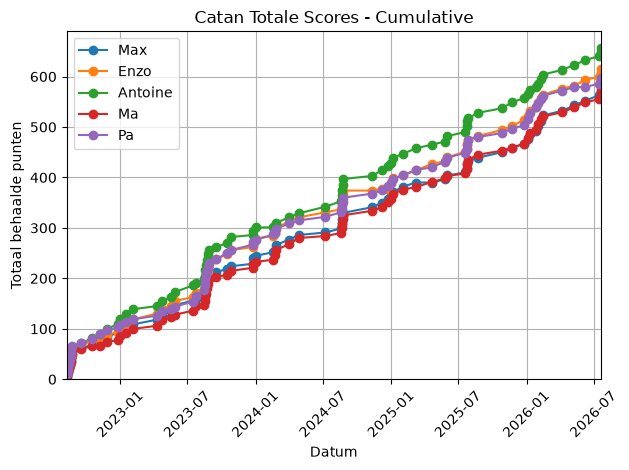

In [38]:
# Plot all cumulative scores
#plt.figure (figsize=(10, 6))
for column in data_x0[["Max", "Enzo", "Antoine", "Ma", "Pa"]]:
   plt.plot(data["Datum"], data_x0[column].cumsum(), label=column, marker='o')#Elke lijn een specifiek marker geven


plt.xlim(data["Datum"].min(), data["Datum"].max())
plt.ylim(ymin=0)

plt.xlabel("Datum")#De dagen waarop niet gespeeld weghalen.
plt.ylabel("Totaal behaalde punten")
plt.title("Catan Totale Scores - Cumulative")#Andere titel
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)#draait de x-as
plt.tight_layout()
#plt.show()

In [40]:
name_graphfile = plt.title
print(f"Titel: {name_graphfile}")

Titel: <function title at 0x7a9104b2e7a0>


In [42]:
#save naar de Graphs map in de Data map
name_graphfile = "Catan_TotaleScores_Alles.png" #aanpassen voor elke grafiek; Gelijk zetten aan de titel van de grafiek
save_path = Path(f"{path_to_folder}/Data/Graphs")
#print("save_path:", save_path) # for checking the path
#save_path.mkdir(exist_ok=True) # To remove the error codes; it makes the map
save_path = save_path / name_graphfile
print("save_path:", save_path)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
#plt.show() #FigureCanvassAgg is non-interactive dus word niet getoond.
print(f"Plot saved as {name_graphfile} in path: {save_path}")

save_path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_TotaleScores_Alles.png
Plot saved as Catan_TotaleScores_Alles.png in path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_TotaleScores_Alles.png


<Figure size 640x480 with 0 Axes>

In [ ]:
#kampioenspunten
data_x0

    Max  Enzo  Antoine  Ma  Pa
0     2     2        2   1   1
3     0     0        0   1   1
4     4     2        1   6   4
5     8     3        2  10   7
6     9    14        7   8   6
7     9    11        8   4  14
8    11     9       13  16  10
9    15     8       14  10   9
10    3     9        4   9   9
11   13     9       15   7  10
12    1     7        7   3   4
13    0     1        2   0   0


/tmp/ipykernel_89574/4058559608.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


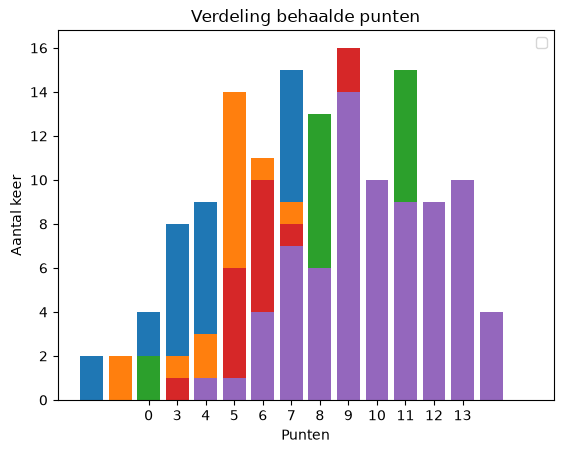

In [ ]:
#Histogrammen maken iedereen bij elkaar
players = ["Max", "Enzo", "Antoine", "Ma", "Pa"]
score_counts = {}


for player in players:
   score_counts[player] = data_x0[player].value_counts().sort_index()

#print(f"score {player}: {score_counts}")

frequency_table = pd.DataFrame(score_counts).fillna(0).astype(int)
print(frequency_table)

x = np.arange(len(frequency_table))
width = 1

for i, player in enumerate(players):
   plt.bar(x + (i *width), frequency_table[player])


plt.xlabel("Punten")
plt.ylabel("Aantal keer")
plt.title("Verdeling behaalde punten")
plt.xticks(x + width * 2, frequency_table.index)
plt.legend()
plt.show()


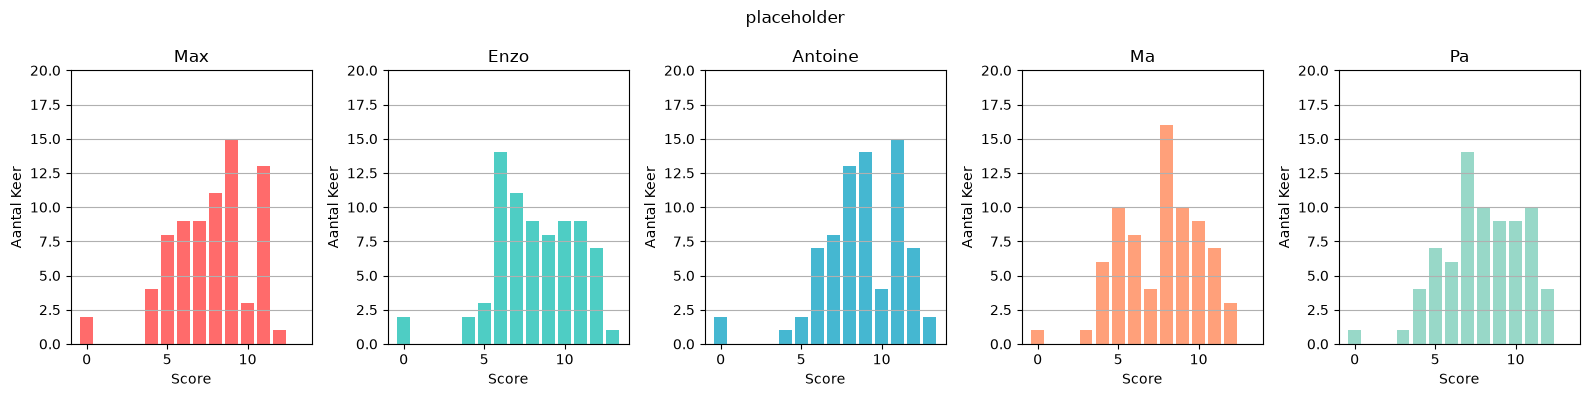

In [100]:
#Histogrammen maken iedereen los
players = ["Max", "Enzo", "Antoine", "Ma", "Pa"]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Maak 5 subplots (1 rij, 5 kolommen)
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, player in enumerate(players):
    # Score frequenties voor deze speler
    score_freq = data_x0[player].value_counts().sort_index()
    
    # Plot in de juiste subplot
    axes[i].bar(score_freq.index, score_freq.values, color=colors[i])
    axes[i].set_title(f"{player}", fontsize=12)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Aantal Keer")
    axes[i].grid(axis='y')
    
    axes[i].set_xlim(-1, 14)
    axes[i].set_ylim(0, 20)

plt.suptitle("placeholder")
plt.tight_layout()
plt.show()


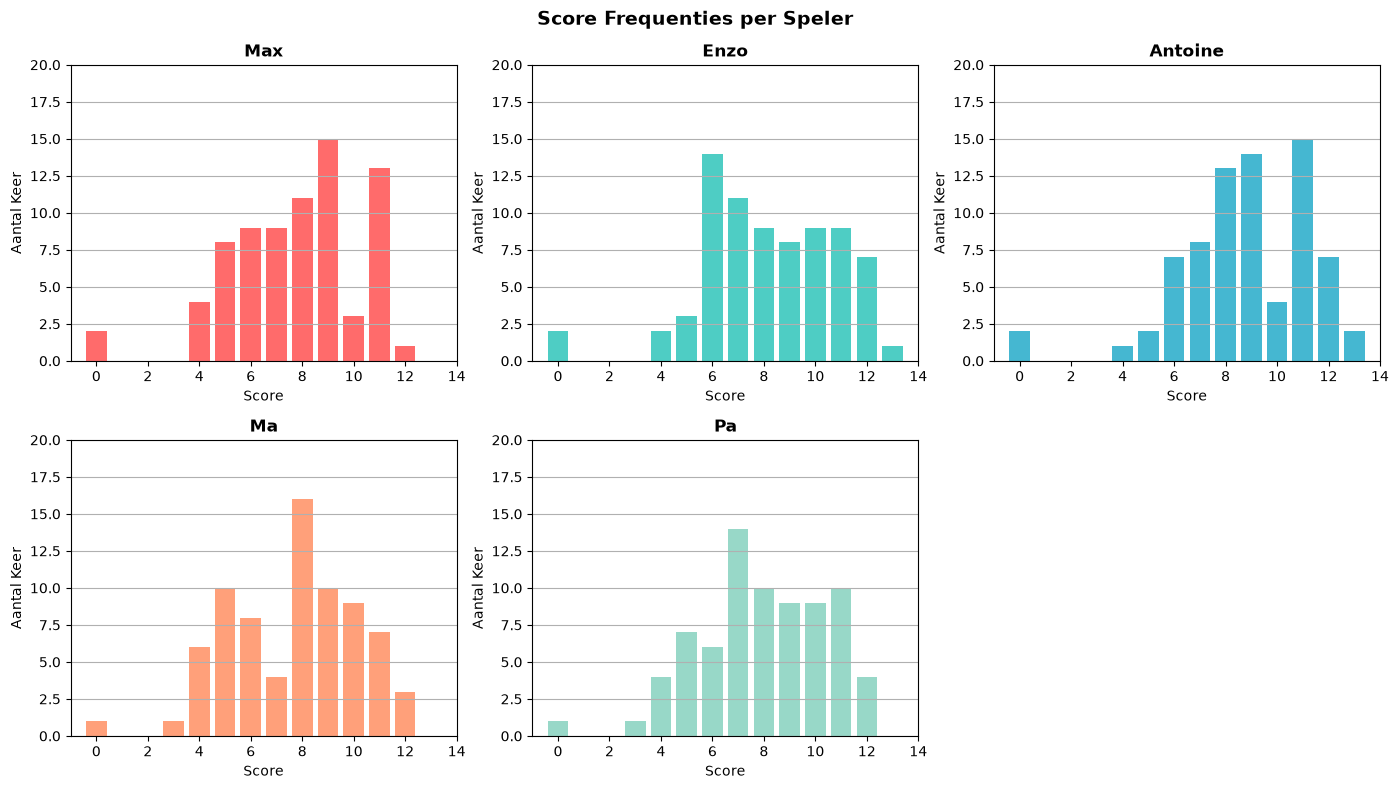

In [ ]:
#Histogrammen maken iedereen los
players = ["Max", "Enzo", "Antoine", "Ma", "Pa"]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, player in enumerate(players):
    score_freq = data_x0[player].value_counts().sort_index()
    
    axes[i].bar(score_freq.index, score_freq.values, color=colors[i],)
    axes[i].set_title(f"{player}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Aantal Keer")
    axes[i].grid(axis='y')
    axes[i].set_xlim(-1, 14)
    axes[i].set_ylim(0, 20)

#axes[5].set_visible(False)

plt.suptitle("Score Frequenties per Speler", fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig("Score_Frequenties_Subplots.png", dpi=300, bbox_inches='tight')
plt.show()